# Metrics Basics

## Setup

### Imports

In [1]:
# Shared Packages
import pandas as pd
import shapely


# Local functions and classes
from utilities import *
from contour_plotting import *
from debug_tools import *


In [2]:
%matplotlib inline

## Algorithms

See: https://shapely.readthedocs.io/en/stable/measurement.html

### Bounds
`shapely.bounds(geometry, **kwargs)`

Compute the bounds (extent) of _each_ geometry.

For _each_ geometry these 4 numbers are returned: min x, min y, max x, max y.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the bounds.

______________

`shapely.total_bounds(geometry, **kwargs)`

Compute the _total_ bounds (extent) of the combined geometries.
For a single geometry `shapely.bounds` and `shapely.total_bounds` will return identical results

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the total bounds.


In [3]:
print("Bounds calculates a bounding box for each geometry")
print("The result is a tuple or list of tuples of (minx, miny, maxx, maxy).")
print(shapely.bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))
print("Total bounds calculates a bounding box that encompasses all geometries")
print("The result is a single tuple of (minx, miny, maxx, maxy).")
print(shapely.total_bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))

Bounds calculates a bounding box for each geometry
The result is a tuple or list of tuples of (minx, miny, maxx, maxy).
[[0. 1. 3. 2.]
 [4. 4. 6. 7.]]
Total bounds calculates a bounding box that encompasses all geometries
The result is a single tuple of (minx, miny, maxx, maxy).
[0. 1. 6. 7.]


_____________

`minimum_bounding_radius(geometry, **kwargs)`

Compute the radius of the minimum bounding circle of an input geometry.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum bounding radius.


In [4]:
print("Minimum Bounding Radius is the radius of the smallest circle around a "
      "polygon. It can be used to estimate the maximum distance between any "
      "two points in a polygon for some shapes.")
box_width = 2
box2 = shapely.Polygon(box_points(width=box_width))
r_2b = shapely.minimum_bounding_radius(box2)
print(f"Maximum distance between any two points of a square of length {box_width}, "
      f"is along the diagonal {2 * r_2b:.2f}.")
triangle_2 = shapely.Polygon([(0, 0), (box_width, 0), (0, box_width)])
r_2t = shapely.minimum_bounding_radius(triangle_2)
print(f"Maximum distance between any two points of a right angle triangle with "
      f"a side length of  length {box_width}, is along the one of the two "
      f"sides ({box_width}), but Minimum Bounding Radius still gives a distance "
      f"of. {2 * r_2t:.2f}.")


Minimum Bounding Radius is the radius of the smallest circle around a polygon. It can be used to estimate the maximum distance between any two points in a polygon for some shapes.
Maximum distance between any two points of a square of length 2, is along the diagonal 2.83.
Maximum distance between any two points of a right angle triangle with a side length of  length 2, is along the one of the two sides (2), but Minimum Bounding Radius still gives a distance of. 2.83.


### Hausdorff distance
`shapely.hausdorff_distance(a, b, densify=None, **kwargs)`

Compute the discrete Hausdorff distance between two geometries.

The Hausdorff distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.

-------

### Fréchet distance

`shapely.frechet_distance(a, b, densify=None, **kwargs)`

Compute the discrete Fréchet distance between two geometries.

The Fréchet distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

Fréchet distance sweep continuously along their respective curves and the direction of curves is significant. This makes it a better measure of similarity than Hausdorff distance for curve or surface matching.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.

The Hausdorff distance is the maximum distance of a contour to the nearest point in the other contour.


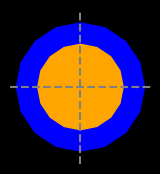

Hausdorff distance: 1.00
Frechet distance: 1.00
In this case this distance between rings is uniform.




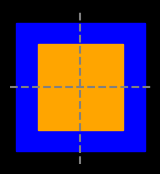

Hausdorff distance: 1.41
Frechet distance: 1.41
In this case the maximum distance is along the diagonal.


In [5]:
print("The Hausdorff distance is the maximum distance of a contour to the "
      "nearest point in the other contour.")

circle6 = shapely.Polygon(circle_points(3))
circle4 = shapely.Polygon(circle_points(2))
d_h = shapely.hausdorff_distance(circle6, circle4)
d_f = shapely.frechet_distance(circle6, circle4)
plot_ab(circle6, circle4)
print(f"Hausdorff distance: {d_h:.2f}")
print(f"Frechet distance: {d_f:.2f}")
print("In this case this distance between rings is uniform.\n\n")

box6 = shapely.Polygon(box_points(6))
box4 = shapely.Polygon(box_points(4))
d_h = shapely.hausdorff_distance(box6, box4)
d_f = shapely.frechet_distance(box6, box4)
plot_ab(box6, box4)
print(f"Hausdorff distance: {d_h:.2f}")
print(f"Frechet distance: {d_f:.2f}")
print("In this case the maximum distance is along the diagonal.")

## Distance
`shapely.distance(a, b, **kwargs)`

Compute the Cartesian distance between two geometries.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.


### Area
`shapley.area(geometry, **kwargs)`

Compute the area of a (multi)polygon.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the area.


### Length
`shapely.length(geometry, **kwargs)`

Compute the length of a (multi)linestring or polygon perimeter.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the length.


### Minimum Clearance
`shapely.minimum_clearance(geometry, **kwargs)`

Compute the Minimum Clearance distance.

A geometry’s “minimum clearance” is the smallest distance by which a vertex of the geometry could be moved to produce an invalid geometry.

If no minimum clearance exists for a geometry (for example, a single point, or an empty geometry), infinity is returned.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum clearance.


## Metric Definitions

### Distance
The Distance metric is the distance between two structures, which is the
minimum distance between any point on the contour of one structure to any point
on the contour of the other structure. On a given slice, this can be calculated
using the Shapely `distance` function.
> $Distance = distance(a,b)$

In the Z direction it is the distance between the closest boundary slices of
$a$ and $b$
> $\Delta Z$

#### Calculation
For the entire structure, the distance is the minimum of the 2D distance and the Z distance:
> $Distance = min( distance(a,b), \Delta Z )$

#### Usage
The Distance metric is well defined for two structures that do not overlap:
- DISJOINT
- SURROUNDS
- SHELTERS

For structures that touch each other (BORDERS), the distance is zero.

For structures that overlap in any way (OVERLAPS, CONTAINS etc.), the distance
is undefined (`NaN`).


#### Examples

##### Disjoint polygons on a plane

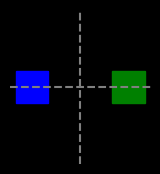

Box Bounds:
	Box A: (-4.0, -1.0, -2.0, 1.0)
	Box B: (2.0, -1.0, 4.0, 1.0)
Distance between boxes is minimum of B minus the maximum of A: 4.0
Shapely distance: 4.0


In [8]:
# 2 2x2 boxes
box2a = shapely.Polygon(box_points(2, offset_x=-3))
box2b = shapely.Polygon(box_points(2, offset_x=3))
plot_ab(box2a, box2b)
print(f"Box Bounds:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
print(f"Distance between boxes is minimum of B minus the maximum of A: "
      f"{box2b.bounds[0] - box2a.bounds[2]}")
print("Shapely distance:", shapely.distance(box2a, box2b))


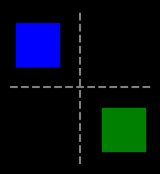

Box Coordinates:
	Box A: (-3.0, 1.0, -1.0, 3.0)
	Box B: (1.0, -3.0, 3.0, -1.0)
Distance between boxes is along the diagonal: 2.83
Shapely distance: 2.83


In [23]:
# 2 2x2 shifted boxes
box2a = shapely.Polygon(box_points(2, offset_x=-2, offset_y=2))
box2b = shapely.Polygon(box_points(2, offset_x=2, offset_y=-2))
plot_ab(box2a, box2b,dicom_orientation=False)
print(f"Box Coordinates:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
minx_a, miny_a, maxx_a, maxy_a = box2a.bounds
minx_b, miny_b, maxx_b, maxy_b = box2b.bounds
print(f"Distance between boxes is along the diagonal: "
      f"{sqrt((minx_b - maxx_a) ** 2 + (miny_a - maxy_b) ** 2):.2f}")
print(f"Shapely distance: {shapely.distance(box2a, box2b):.2f}")


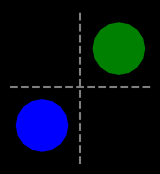

Box Coordinates:
\Circle A: (-5.0, 1.0, -1.0, 5.0)
\Circle B: (1.0, -5.0, 5.0, -1.0)
Box Coordinates:
	Box A: (-5.0, 1.0, -1.0, 5.0)
	Box B: (1.0, -5.0, 5.0, -1.0)
Distance between circle is the distance between there centres minus the circle diameters: 4.49
Shapely distance: 4.49


In [ ]:
circle_diameter = 4
circle_a_centre = (-3, 3)
circle_b_centre = (3, -3)
circle_a = shapely.Polygon(circle_points(radius=circle_diameter/2,
                                         offset_x=circle_a_centre[0],
                                         offset_y=circle_a_centre[1]))
circle_b = shapely.Polygon(circle_points(radius=circle_diameter/2,
                                         offset_x=circle_b_centre[0],
                                         offset_y=circle_b_centre[1]))
plot_ab(circle_a, circle_b)
print(f"Box Coordinates:\n\Circle A: {circle_a.bounds}\n\Circle B: {circle_b.bounds}")

print(f"Box Coordinates:\n\tBox A: {circle_a.bounds}\n\tBox B: {circle_b.bounds}")
distance_between_centres = sqrt((circle_b_centre[0] - circle_a_centre[0]) ** 2 + (circle_a_centre[1] - circle_b_centre[1]) ** 2)
distance_between_circles = distance_between_centres - circle_diameter
print(f"Distance between circle is the distance between there centres minus the circle diameters: {distance_between_circles:.2f}")
print(f"Shapely distance: {shapely.distance(circle_a, circle_b):.2f}")


#### Surrounding / Surrounded structures

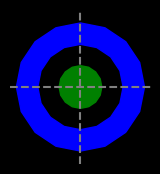

The Distance between the circle and the ring is the ring's inner radius minus the circle radius: 1.00
Shapely distance: 0.98
We are seeing a resolution effect here.


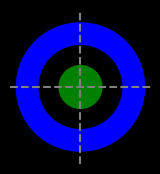

Shapely distance: 1.00
With a higher number of points the distance becomes correct.


In [31]:
circle6 = shapely.Polygon(circle_points(radius=3))
circle4 = shapely.Polygon(circle_points(radius=2))
circle2 = shapely.Polygon(circle_points(radius=1))

ring_a = circle6 - circle4
circle_b = circle2
plot_ab(ring_a, circle_b)
print(f"The Distance between the circle and the ring is the ring's inner radius minus the circle radius: {2 - 1:.2f}")
print(f"Shapely distance: {shapely.distance(ring_a, circle_b):.2f}")
print("We are seeing a resolution effect here.")

circle6 = shapely.Polygon(circle_points(radius=3, num_points=1000))
circle4 = shapely.Polygon(circle_points(radius=2, num_points=1000))
circle2 = shapely.Polygon(circle_points(radius=1, num_points=1000))
ring_a = circle6 - circle4
circle_b = circle2
plot_ab(ring_a, circle_b)
print(f"Shapely distance: {shapely.distance(ring_a, circle_b):.2f}")
print("With a higher number of points the distance becomes correct.")


# Done to Here

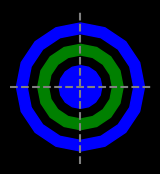

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-2.0, -2.0, 2.0, 2.0)
Bounds difference: [-1. -1.  1.  1.]
Shapely distance: 0.4903088029200839
Hausdorff distance: 1.0002324729781569
Frechet distance: 2.4540725335653795


In [9]:
circle6 = shapely.Polygon(circle_points(3))
circle5 = shapely.Polygon(circle_points(2.5))
circle4 = shapely.Polygon(circle_points(2))
circle3 = shapely.Polygon(circle_points(1.5))
circle2 = shapely.Polygon(circle_points(1))

ring_dot_a = (circle6 - circle5).union(circle2)
ring_b = circle4 - circle3

plot_ab(ring_dot_a, ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {ring_dot_a.bounds}\n\tCircle B: {ring_b.bounds}")
print("Bounds difference:", np.array(ring_dot_a.bounds) - np.array(ring_b.bounds))
print("Shapely distance:", shapely.distance(ring_dot_a, ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(ring_dot_a, ring_b))
print("Frechet distance:", shapely.frechet_distance(ring_dot_a, ring_b))

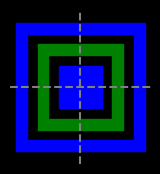

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-2.0, -2.0, 2.0, 2.0)
Bounds difference: [-1. -1.  1.  1.]
Shapely distance: 0.5
Hausdorff distance: 1.4142135623730951
Frechet distance: 5.0990195135927845


In [10]:
box6 = shapely.Polygon(box_points(6))
box5 = shapely.Polygon(box_points(5))
box4 = shapely.Polygon(box_points(4))
box3 = shapely.Polygon(box_points(3))
box2 = shapely.Polygon(box_points(2))

ring_box_a = (box6 - box5).union(box2)
box_ring_b = box4 - box3

plot_ab(ring_box_a, box_ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {ring_box_a.bounds}\n\tCircle B: {box_ring_b.bounds}")
print("Bounds difference:", np.array(ring_box_a.bounds) - np.array(box_ring_b.bounds))
print("Shapely distance:", shapely.distance(ring_box_a, box_ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(ring_box_a, box_ring_b))
print("Frechet distance:", shapely.frechet_distance(ring_box_a, box_ring_b))

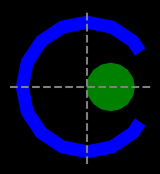

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 2.436989745200003, 3.0)
	Circle B: (0.0, -1.0, 2.0, 1.0)
Bounds difference: [-3.         -2.          0.43698975  2.        ]
Shapely distance: 0.7250695536892662
Hausdorff distance: 3.0
Frechet distance: 3.0


In [12]:
circle6 = shapely.Polygon(circle_points(3))
circle5 = shapely.Polygon(circle_points(2.5))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=3.5))
shell = shapely.difference(circle6, circle5)
cove = shapely.difference(shell, circle4_offset)
circle2 = shapely.Polygon(circle_points(1, offset_x=1))

plot_ab(cove, circle2)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {cove.bounds}\n\tCircle B: {circle2.bounds}")
print("Bounds difference:", np.array(cove.bounds) - np.array(circle2.bounds))
print("Shapely distance:", shapely.distance(cove, circle2))
print("Hausdorff distance:", shapely.hausdorff_distance(cove, circle2))
print("Frechet distance:", shapely.frechet_distance(cove, circle2))

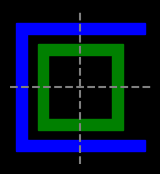

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-3.0, -3.0, 3.0, 3.0)
Bounds difference: [0. 0. 0. 0.]
Shapely distance: 0.5
Hausdorff distance: 1.4142135623730951
Frechet distance: 4.743416490252569


In [13]:
box6 = shapely.Polygon(box_points(6))
box5 = shapely.Polygon(box_points(width=7, height=5, offset_x=1))
box4 = shapely.Polygon(box_points(4))
box3 = shapely.Polygon(box_points(3))
box2 = shapely.Polygon(box_points(2))

box_cove_a = (box6 - box5)
box_ring_b = box4 - box3

plot_ab(box_cove_a, box_ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {box_cove_a.bounds}\n\tCircle B: {box_cove_a.bounds}")
print("Bounds difference:", np.array(box_cove_a.bounds) - np.array(box_cove_a.bounds))
print("Shapely distance:", shapely.distance(box_cove_a, box_ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(box_cove_a, box_ring_b))
print("Frechet distance:", shapely.frechet_distance(box_cove_a, box_ring_b))